**Generative AI Use**: For the purposes of the assignments, the use of generative AI is subject to the same policies regarding collaboration. Just as with other collaborators, each student must write down the solutions independently of the output of the interaction and the submission should include a note denoting the nature of the collaboration. The use of generative AI tools to substantially complete sections of the assignments is not in line with the spirit of the assignments, and would be a violation of the [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# Softmax Classifier exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the Softmax classifier.
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [26]:
# Run some setup code for this notebook.
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline 
# 图片直接在单元格内显示，不新开窗口
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2 
#修改 py 文件后自动重载，不用重启内核

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## CIFAR-10 Data Loading and Preprocessing

In [27]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Clear previously loaded data.
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


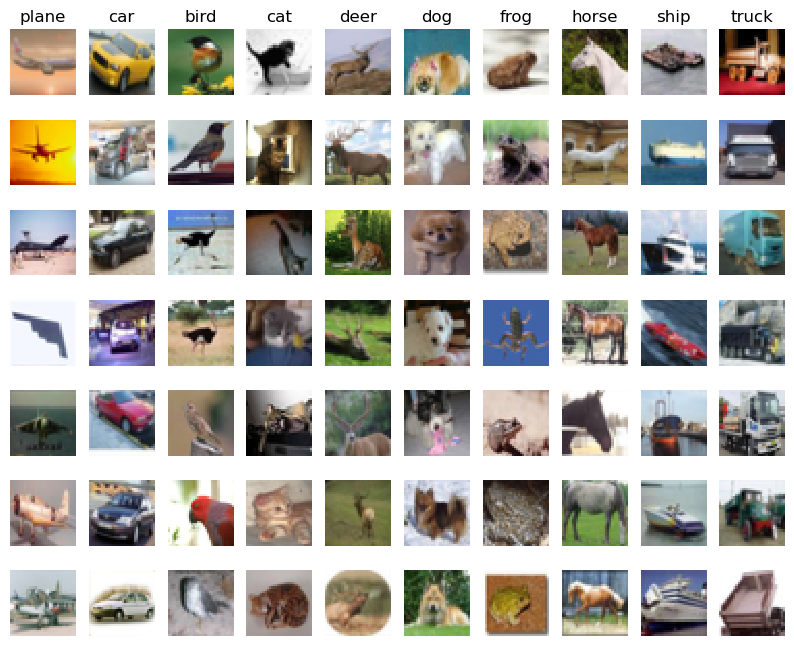

In [28]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [29]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
# 设定四份数据集数量：训练集4.9w，验证集1k，测试集1k，开发集0.5k
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
# ========== 1. 从原始5w训练集尾部切1000做验证集val ==========
# range(49000,50000) 下标：49000~49999 共1000个样本
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
# ========== 2. 剩余前49000作为新的训练集train ==========
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
# ========== 3. 从新训练集里无放回随机选500 → dev小开发集 ==========
# replace=False：不重复抽样，dev用来快速跑代码、调bug、试超参
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
# ========== 4. 原测试集取前1000做最终test ==========
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


### 为什么dev要从train里抽，不直接在原始大训练集取
  若错误做法：dev 从原始 50000 里随便抽 很有可能抽到本该划入 val 的 1000 条样本： • 你调试代码、试超参时模型提前见过 val 数据； • 后续用 val 选超参时，val 指标虚高，误以为模型效果好； • 最终 test 性能暴跌（过拟合到 val）。

数据集	样本量	使用场景
* X_train(49000)	正式训练集	训练 kNN/SVM/ 全连接网络，参数更新
* X_val(1000)	验证集	调超参 (学习率、正则系数)、选最优模型，不能参与训练
* X_dev(500)	开发小集	代码调试、快速跑通损失 / 梯度，避免大数据训练太慢
* X_test(1000)	测试集	全程最后只用 1 次，评估模型真实泛化能力，不能用来调参

In [30]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


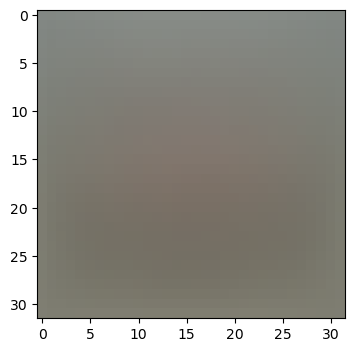

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [31]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)

print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()
#axis=0： 按样本维度求均值 ，得到和单张图片尺寸一致的平均图像；只用 训练集 算均值，避免验证 / 测试集信息泄露。 • 
# 绘图：把均值张量还原为32×32×3RGB 图片可视化全局平均像素。

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image
#消除像素整体亮度偏移、中心化特征 ，加速线性分类 / 梯度下降收敛

# third: append the bias dimension of ones (i.e. bias trick) so that our classifier
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

### hstack是拼接函数吗，改变原来矩阵的维数吗
* 给原数组加了全一列，把偏置直接塞进权重矩阵最后一列，不用单独写+b，代码简化。
* np.hstack不会原地修改原数组，是生成新数组，再赋值覆盖X_train，所以变量维度变了； 
* 如果是纵向拼接 vstack：上下拼，加行、列不变。

## Softmax Classifier

Your code for this section will all be written inside `cs231n/classifiers/softmax.py`.

As you can see, we have prefilled the function `softmax_loss_naive` which uses for loops to evaluate the softmax loss function.

In [32]:
# Evaluate the naive implementation of the loss we provided for you:
from cs231n.classifiers.softmax import softmax_loss_naive
import time

#高斯权重初始化，权重矩阵维度：3073×10（3072维像素+1维偏置，10类输出）
# generate a random Softmax classifier weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
#loss标量，样本平均 Softmax 交叉熵 + L2 正则损失 
# grad用来梯度下降更新权重
print('loss: %f' % (loss, ))

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.363160
loss: 2.363160
sanity check: 2.302585


##### print('sanity check: %f' % (-np.log(0.1))) 这个不是一个常量吗，不管什么样的损失函数都是同一值，怎么校验
 * -np.log(0.1)是10 分类 Softmax 初始状态的理论标准答案
 * 刚初始化 W，还没训练、reg 设极小 
 * 输出 loss ≈2.3 → softmax 公式、指数、归一、log 全都大概率写对 
 * loss >>2.3 或 <<2.3：代码出错： 
 *  指数没归一、分母求和错 
 *  取 log 位置反了、正负号写错 
 *   维度错乱（样本 / 类别搞反）

**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

$\color{blue}{\textit Your Answer:}$ *Fill this in*



The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the softmax loss function and implement it inline inside the function `softmax_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

grad：你手推公式算出的解析梯度（analytic grad） 
grad_check_sparse：用微小扰动算数值梯度（numerical grad）

In [33]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

#reg=0.0，关掉正则，只校验数据损失的梯度
# Compute the loss and its gradient at W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
#reg=5e1 打开正则，校验正则梯度有没有加上
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 1.548202 analytic: 1.548202, relative error: 1.356467e-08
numerical: 0.069130 analytic: 0.069129, relative error: 8.878994e-07
numerical: 0.452356 analytic: 0.452356, relative error: 3.138240e-08
numerical: -0.483823 analytic: -0.483823, relative error: 6.452258e-09
numerical: 1.092844 analytic: 1.092844, relative error: 6.754786e-09
numerical: -0.436106 analytic: -0.436106, relative error: 6.295960e-08
numerical: -1.305786 analytic: -1.305786, relative error: 1.820177e-08
numerical: 1.563180 analytic: 1.563180, relative error: 2.931428e-08
numerical: 0.642118 analytic: 0.642118, relative error: 1.423758e-09
numerical: -2.200908 analytic: -2.200908, relative error: 7.493100e-09
numerical: 0.263068 analytic: 0.263068, relative error: 8.601922e-08
numerical: 1.687356 analytic: 1.687356, relative error: 8.908999e-09
numerical: -0.430563 analytic: -0.430563, relative error: 4.798685e-08
numerical: -0.039260 analytic: -0.039260, relative error: 2.294028e-07
numerical: -5.033506 a

 1. lambda w: ...[0]：固定 X,y,reg 不动，只把 W 当变量，符合数值梯度输入要求； 
 1. 只用小数据集X_dev(500 样本) 做梯度检查，计算快； 
 2. sparse 稀疏校验：随机挑几个 W 的位置验算，不用全矩阵对比，节省算力。  
#### 常见错误 
1. 第一轮过、第二轮报错：正则梯度 λ*W 没加到 grad 上 
2.  两轮误差都很大：Softmax 反向传播求导公式写错（dS/dW 出错）

**Inline Question 2**

Although gradcheck is reliable softmax loss, it is possible that for SVM loss, once in a while, a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a svm loss gradient check could fail? How would change the margin affect of the frequency of this happening?

Note that SVM loss for a sample $(x_i, y_i)$ is defined as: $$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$ where $j$ iterates over all classes except the correct class $y_i$ and $s_j$ denotes the classifier score for $j^{th}$ class. $\Delta$ is a scalar margin. For more information, refer to 'Multiclass Support Vector Machine loss' on [this](https://cs231n.github.io/linear-classify/) page.

*Hint: the SVM loss function is not strictly speaking differentiable.*


$\color{blue}{\textit Your Answer:}$ *SVM 的 Hinge 损失依靠，在  拐点处不可导，解析梯度采用次梯度取值，有限差分法的数值梯度在拐点附近会取到另一侧导数，二者数值不一致，因此 gradcheck 偶尔出错。该误差无需担心，仅少量参数落在拐点才出现，不影响整体训练。一维示例： 时解析梯度取 0，数值差分算得 0.5，二者不等。增大间隔  会减少样本落在拐点的概率，降低梯度不匹配出现频次；减小  会提升出错概率。*  



In [34]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
#记录开始时间
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))
# %e：科学计数法打印损失值
#利用循环计算损失

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))
#向量化实现计算损失

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))
#损失数值应该完全一样，但向量化实现应该快很多。

Naive loss: 2.363160e+00 computed in 0.024170s
Vectorized loss: 2.363160e+00 computed in 0.001774s
difference: 0.000000


In [35]:
# Complete the implementation of softmax_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
#弗罗贝尼乌斯范数 ，等价于矩阵所有元素平方和再开根号。
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.040227s
Vectorized loss and gradient: computed in 0.002584s
difference: 0.000000


梯度是二维矩阵，没法直观对比。F 范数把整张矩阵的误差汇总成一个数： • 数值越接近 0 → 两个梯度几乎完全一致 • 数值越大 → 实现出错、梯度偏差大
#### 作业里一般要求这个值小于10^-6或 10^-8 就算正确。

### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `cs231n/classifiers/linear_classifier.py`.

In [36]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from cs231n.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
#训练1500轮，学习率1e-7，正则化强度2.5e4,保留损失值
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 386.182583
iteration 100 / 1500: loss 233.959047
iteration 200 / 1500: loss 141.936622
iteration 300 / 1500: loss 86.828800
iteration 400 / 1500: loss 53.370664
iteration 500 / 1500: loss 33.100346
iteration 600 / 1500: loss 20.728610
iteration 700 / 1500: loss 13.388309
iteration 800 / 1500: loss 8.907889
iteration 900 / 1500: loss 6.178567
iteration 1000 / 1500: loss 4.541272
iteration 1100 / 1500: loss 3.498293
iteration 1200 / 1500: loss 2.934889
iteration 1300 / 1500: loss 2.503723
iteration 1400 / 1500: loss 2.386672
That took 1.648868s


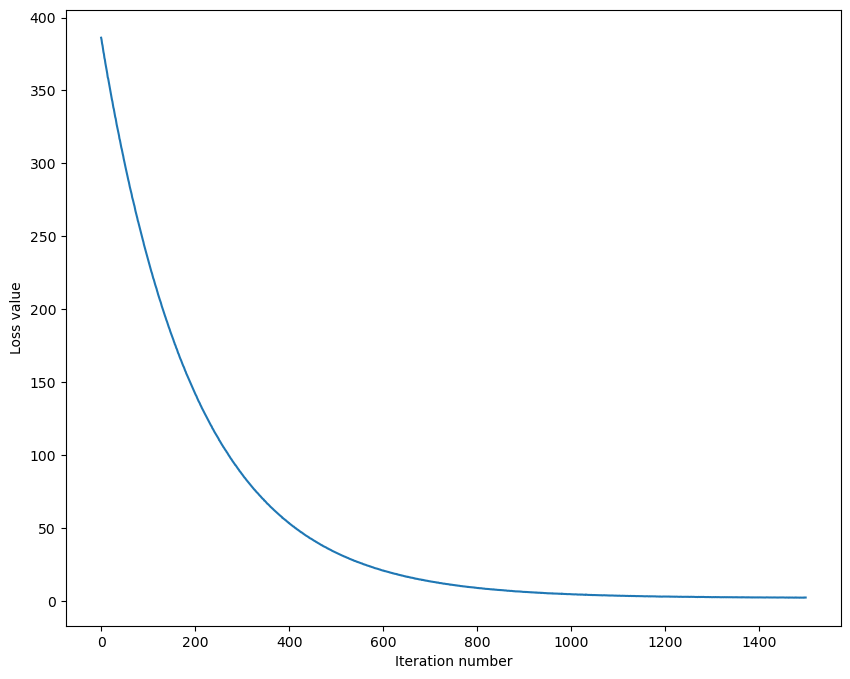

In [37]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [38]:
# Write the LinearClassifier.predict function and evaluate the performance on
# both the training and validation set
# You should get validation accuracy of about 0.34 (> 0.33).
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.346735
validation accuracy: 0.358000


In [39]:
# Save the trained model for autograder.
softmax.save("softmax.npy")

softmax.npy saved.


In [40]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.365 (> 0.36) on the validation set.

# Note: you may see runtime/overflow warnings during hyper-parameter search.
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_softmax = None # The Softmax object that achieved the highest validation rate.

# 定义待搜索的超参列表：学习率、正则系数
learning_rates = [1e-7, 5e-7, 1e-6, 2e-6, 5e-6]
regularization_strengths = [1e3, 5e3, 1e4, 2e4, 5e4]

results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_softmax = None # The Softmax object that achieved the highest validation rate.

# 遍历所有超参组合
for lr in learning_rates:
    for reg in regularization_strengths:
        # 1. 初始化并训练 Softmax 分类器
        softmax = Softmax()
        # 迭代次数：调试用小值，最终跑结果可改大（如 1500）
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=2000, verbose=False)
        
        # 2. 预测并计算训练集、验证集准确率
        y_train_pred = softmax.predict(X_train)
        train_acc = np.mean(y_train_pred == y_train)
        
        y_val_pred = softmax.predict(X_val)
        val_acc = np.mean(y_val_pred == y_val)
        
        # 3. 存入结果字典
        results[(lr, reg)] = (train_acc, val_acc)
        
        # 4. 更新最优模型 & 最优验证集精度
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax

# 打印所有组合结果 & 最优结果
for lr, reg in sorted(results):
    train_acc, val_acc = results[(lr, reg)]
    print(f'lr {lr:e}, reg {reg:e} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}')
    
print(f'\nBest validation accuracy achieved: {best_val:.4f}')
################################################################################
# TODO:                                                                        #
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a Softmax on the.        #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the Softmax object that achieves this.   #
# accuracy in best_softmax.                                                    #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the classifiers don't take much time to train; once  #
# you are confident that your validation code works, you should rerun the      #
# code with a larger value for num_iters.                                      #
################################################################################

# Provided as a reference. You may or may not want to change these hyperparameters
learning_rates = [1e-7, 1e-6]
regularization_strengths = [2.5e4, 1e4]



# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07, reg 1.000000e+03 | train acc: 0.2733 | val acc: 0.2890
lr 1.000000e-07, reg 5.000000e+03 | train acc: 0.3225 | val acc: 0.3220
lr 1.000000e-07, reg 1.000000e+04 | train acc: 0.3574 | val acc: 0.3710
lr 1.000000e-07, reg 2.000000e+04 | train acc: 0.3562 | val acc: 0.3670
lr 1.000000e-07, reg 5.000000e+04 | train acc: 0.3228 | val acc: 0.3400
lr 5.000000e-07, reg 1.000000e+03 | train acc: 0.3840 | val acc: 0.3800
lr 5.000000e-07, reg 5.000000e+03 | train acc: 0.3844 | val acc: 0.3910
lr 5.000000e-07, reg 1.000000e+04 | train acc: 0.3713 | val acc: 0.3880
lr 5.000000e-07, reg 2.000000e+04 | train acc: 0.3512 | val acc: 0.3760
lr 5.000000e-07, reg 5.000000e+04 | train acc: 0.3167 | val acc: 0.3380
lr 1.000000e-06, reg 1.000000e+03 | train acc: 0.4123 | val acc: 0.4170
lr 1.000000e-06, reg 5.000000e+03 | train acc: 0.3817 | val acc: 0.3850
lr 1.000000e-06, reg 1.000000e+04 | train acc: 0.3656 | val acc: 0.3890
lr 1.000000e-06, reg 2.000000e+04 | train acc: 0.3475 | val acc:

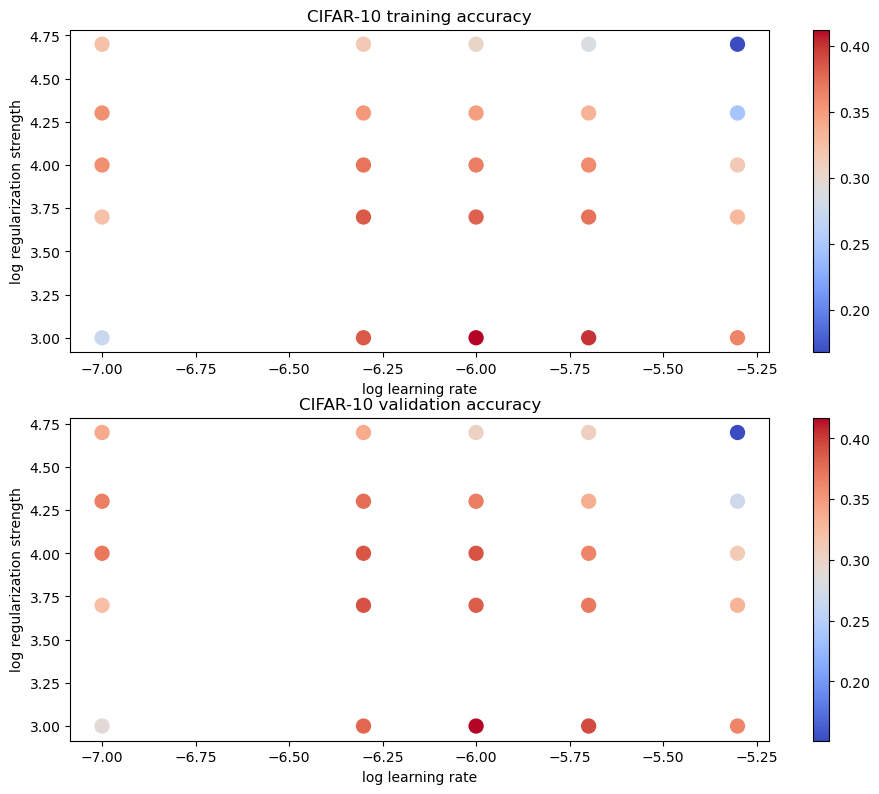

In [41]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [42]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

Softmax classifier on raw pixels final test set accuracy: 0.398000


In [43]:
# Save best softmax model
best_softmax.save("best_softmax.npy")

best_softmax.npy saved.


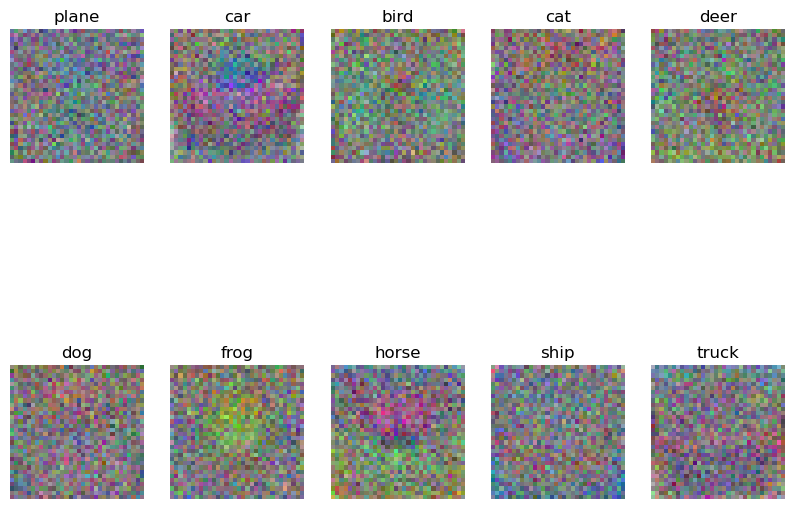

In [44]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Inline question 3**

Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.

$\color{blue}{\textit Your Answer:}$ *可视化后的权重是形似对应类别的模糊模板。线性分类器会学习各类别的典型特征作为匹配模板，权重融合了大量同类样本的特征，个体细节被平均，因此呈现出模糊的效果*  


**Inline Question 4** - *True or False*

Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would change the softmax loss, but leave the SVM loss unchanged.

$\color{blue}{\textit Your Answer:}$ 正确


$\color{blue}{\textit Your Explanation:}$ SVM 损失原理SVM 采用间隔损失，只对不满足分类间隔的样本产生损失。若新增样本本身分类正确、且得分差距超过设定间隔，它的单样本损失为 0，整体 SVM 总损失就不会改变。 2. Softmax 损失原理Softmax 是基于概率分布的交叉熵损失，只要新增样本存在，就一定会产生非零损失，必然让整体 Softmax 总损失变大。

